# 0. 환경설정

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import seaborn as sns
from scipy import stats
plt.rcParams['font.family'] = 'Malgun Gothic'  # 한글 깨짐 방지 (Windows)
plt.rcParams['axes.unicode_minus'] = False

# 1. Withdrawn 반영

## 1. 이탈률 정의

In [83]:
# 1-1 CSV 파일 불러오기 (이탈 라벨의 출처는 studentInfo.csv)

info = pd.read_csv("../../CSV_files/studentInfo.csv")
info[['code_module', 'code_presentation', 'id_student', 'final_result']].head()

,code_module,code_presentation,id_student,final_result
0,AAA,2013J,11391,Pass
1,AAA,2013J,28400,Pass
2,AAA,2013J,30268,Withdrawn
3,AAA,2013J,31604,Pass
4,AAA,2013J,32885,Pass


In [84]:
# 1-2 final_result 분포 확인

info['final_result'].value_counts()

# Pass / Fail / Distinction / Withdrawn 4개 범주
# 이 중 '이탈'에 해당하는 건 Withdrawn뿐 -> Fail은 끝까지 다녔지만 불합격한 경우라 이탈과는 다름

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

### 이탈 라벨 정의: `final_result == 'Withdrawn'`

이탈 여부를 판단할 수 있는 후보는 두 가지였다. ① `studentInfo.csv`의 `final_result`(Withdrawn 여부),
② `studentRegistration.csv`의 `date_unregistration`(실제 등록취소 시점). 앞서 확인한 대로 두 값은
99% 가까이 일치하지만 완전히 같지는 않다(Withdrawn인데 취소일이 없는 93건, Fail인데 취소일이
있는 9건). 이번 노트북에서는 **"이탈 여부"의 기준값(라벨)은 `final_result == 'Withdrawn'`으로
고정**한다. `date_unregistration`은 라벨이 아니라 "언제 이탈했는지"를 보여주는 타이밍 정보로,
7장(추가 조인 필요 항목)에서 별도로 다룬다.

In [85]:
# 1-3 이탈 라벨(label_churn) 생성 및 전체 이탈률

info['label_churn'] = (info['final_result'] == 'Withdrawn').astype(int)
print('전체 학생-과목 등록 건수:', len(info))
print('전체 이탈률:', round(info['label_churn'].mean(), 4))
info['label_churn'].value_counts(normalize=True).round(3)

전체 학생-과목 등록 건수: 32593
전체 이탈률: 0.3116


label_churn
0    0.688
1    0.312
Name: proportion, dtype: float64

### 조인 전에 먼저 확인해야 하는 것: "제출 이력 자체가 없는" 학생

이번 노트북은 studentAssessment.csv를 기준으로 assessments.csv, studentInfo.csv를 조인해서
분석한다. 그런데 조인을 하기 전에 반드시 짚어야 할 문제가 있다 — **studentAssessment.csv에는
평가를 한 건도 제출하지 않은 학생은 아예 행 자체가 없다.** 이 학생들이 이탈과 어떤 관계인지
먼저 확인하지 않으면, 조인 이후의 모든 분석이 "이미 어느 정도 참여한 학생들 사이의 차이"로
왜곡될 수 있다.

In [86]:
# 1-4 제출 이력 유무와 이탈률의 관계 (조인 전 사전 점검)

sa_check = pd.read_csv("../../CSV_files/studentAssessment.csv")
asm_check = pd.read_csv("../../CSV_files/assessments.csv")

submitted_keys = (
    sa_check.merge(asm_check[['id_assessment', 'code_module', 'code_presentation']], on='id_assessment', how='left')
    [['code_module', 'code_presentation', 'id_student']]
    .drop_duplicates()
)

roster = info[['code_module', 'code_presentation', 'id_student', 'label_churn', 'final_result']].drop_duplicates()
roster = roster.merge(submitted_keys.assign(has_submission=1),
                       on=['code_module', 'code_presentation', 'id_student'], how='left')
roster['has_submission'] = roster['has_submission'].fillna(0)

print('제출 이력이 하나라도 있는 학생-과목:', int(roster['has_submission'].sum()), f"({roster['has_submission'].mean():.1%})")
print()
print('제출 이력 유무별 이탈률')
print(roster.groupby('has_submission')['label_churn'].mean().round(3))

제출 이력이 하나라도 있는 학생-과목: 25843 (79.3%)

제출 이력 유무별 이탈률
has_submission
0.0    0.809
1.0    0.182
Name: label_churn, dtype: float64


**[핵심 발견]** 전체 32,593건 중 20.7%(6,750건)는 studentAssessment.csv에 단 한 건의 제출
기록도 없다. 그런데 이 그룹의 이탈률은 80.9%로, 제출 이력이 있는 그룹의 이탈률(18.2%)보다
4.4배 높다. 즉 **"평가를 한 번이라도 제출했는가"** 자체가 이미 가장 강력한 이탈 신호이고,
이 노트북에서 만들 조인 테이블(studentAssessment 기준)은 처음부터 이 고위험군을 포함하지
못한다는 뜻이다. 이후 모든 분석 결과는 이 사실을 전제로 해석해야 한다.

## 2. 데이터 조인

### 조인 경로

studentAssessment.csv에는 `code_module`, `code_presentation`이 없어서 studentInfo.csv와 바로
붙일 수 없다. 그래서 다음 순서로 조인한다.

1. **studentAssessment**(기준, 학생×제출 단위) + **assessments**(`id_assessment`로 조인)
   → `code_module`, `code_presentation`, `assessment_type`, 마감일(`date`), `weight` 확보
2. 위 결과 + **studentInfo**(`code_module`, `code_presentation`, `id_student` 세 키로 조인)
   → `final_result`, `label_churn` 확보

`id_student` 하나만으로 조인하면 안 되는 이유도 재확인한다 — 학생의 12.3%가 여러
module-presentation에 등록돼 있어서, `id_student`만으로 조인하면 한 제출 건에 엉뚱한 학기의
결과가 잘못 붙는다.

In [87]:
# 2-1 잘못된 조인 예시 재확인 (id_student만 사용 -> 행이 부풀려짐)

sa = pd.read_csv("../../CSV_files/studentAssessment.csv")
asm = pd.read_csv("../../CSV_files/assessments.csv")

bad_join = sa.merge(info[['id_student', 'final_result']], on='id_student', how='left')
print('원본 studentAssessment 행 수:', len(sa))
print('id_student만으로 조인했을 때 행 수:', len(bad_join), '-> 행이 늘어남(잘못된 조인)')

원본 studentAssessment 행 수: 173912
id_student만으로 조인했을 때 행 수: 207319 -> 행이 늘어남(잘못된 조인)


In [88]:
# 2-2 올바른 조인 실행

df = sa.merge(asm, on='id_assessment', how='left')
print('1단계(assessments 조인) 후 행 수:', len(df), ' code_module 결측:', df['code_module'].isna().sum())

df = df.merge(
    info[['code_module', 'code_presentation', 'id_student', 'final_result', 'label_churn']],
    on=['code_module', 'code_presentation', 'id_student'], how='left'
)
print('2단계(studentInfo 조인) 후 행 수:', len(df), ' label_churn 결측:', df['label_churn'].isna().sum())

# ! 두 단계 모두 원본(173,912)과 행 수가 같고 결측도 없음 -> 올바르게 조인됨(행 폭발/누락 없음)

1단계(assessments 조인) 후 행 수: 173912  code_module 결측: 0
2단계(studentInfo 조인) 후 행 수: 173912  label_churn 결측: 0


In [89]:
# 2-3 파생변수 생성: delay(제출 지연일수) = 실제 제출일 - 마감일
# 양수면 지각 제출, 음수면 조기 제출

df['delay'] = df['date_submitted'] - df['date']
df[['id_assessment', 'id_student', 'code_module', 'code_presentation', 'assessment_type',
    'date', 'date_submitted', 'delay', 'weight', 'score', 'final_result', 'label_churn']].head()

,id_assessment,id_student,code_module,code_presentation,assessment_type,date,date_submitted,delay,weight,score,final_result,label_churn
0,1752,11391,AAA,2013J,TMA,19.0,18,-1.0,10.0,78.0,Pass,0
1,1752,28400,AAA,2013J,TMA,19.0,22,3.0,10.0,70.0,Pass,0
2,1752,31604,AAA,2013J,TMA,19.0,17,-2.0,10.0,72.0,Pass,0
3,1752,32885,AAA,2013J,TMA,19.0,26,7.0,10.0,69.0,Pass,0
4,1752,38053,AAA,2013J,TMA,19.0,19,0.0,10.0,79.0,Pass,0


**참고:** 이 조인 테이블은 173,912건(제출 이력이 있는 건)만 담고 있다. 1장에서 확인한
"제출 이력이 아예 없는" 6,750건(고위험 이탈군)은 이 테이블에 없다는 사실을 계속 염두에 두고
아래 분석을 읽어야 한다.

## 3. 개요

### 1. 기본정보

In [90]:
# 3-1 정보

df.info()

# ? delay, date(마감일)의 결측 2,865건은 왜 있는가? -> assessments.csv에서 Exam 마감일 결측(11건)이 원인일 가능성

<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_assessment      173912 non-null  int64  
 1   id_student         173912 non-null  int64  
 2   date_submitted     173912 non-null  int64  
 3   is_banked          173912 non-null  int64  
 4   score              173739 non-null  float64
 5   code_module        173912 non-null  str    
 6   code_presentation  173912 non-null  str    
 7   assessment_type    173912 non-null  str    
 8   date               171047 non-null  float64
 9   weight             173912 non-null  float64
 10  final_result       173912 non-null  str    
 11  label_churn        173912 non-null  int64  
 12  delay              171047 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 17.2 MB


In [91]:
# 3-2 기술통계
# id_assessment, id_student는 식별자성 외래키라 제외

df[['date_submitted', 'date', 'weight', 'delay', 'score']].describe()

# delay는 중앙값 -1일로 대부분 마감 직전~직후에 제출, 평균은 -16.7일로 매우 이른 제출도 섞여 있어 평균이 더 왼쪽으로 당겨짐

,date_submitted,date,weight,delay,score
count,173912.000000,171047.000000,173912.000000,171047.000000,173739.000000
mean,116.032942,130.605623,12.743899,-16.657989,75.799573
std,71.484148,78.025175,17.877301,45.945880,18.798107
min,-11.000000,12.000000,0.000000,-246.000000,0.000000
25%,51.000000,54.000000,0.000000,-6.000000,65.000000
50%,116.000000,129.000000,9.000000,-1.000000,80.000000
75%,173.000000,214.000000,18.000000,2.000000,90.000000
max,608.000000,261.000000,100.000000,372.000000,100.000000


In [92]:
# 3-3 결측치 위치 조회

df.isna().sum()

id_assessment           0
id_student              0
date_submitted          0
is_banked               0
score                 173
code_module             0
code_presentation       0
assessment_type         0
date                 2865
weight                  0
final_result            0
label_churn             0
delay                2865
dtype: int64

In [93]:
# date(마감일) 결측 원인 확인

na_date = df[df['date'].isna()]
print('date(마감일) 결측 건수:', len(na_date))
print(na_date['assessment_type'].value_counts())

# ! 전부 Exam 유형 -> 01번(assessments.csv) 노트북에서 확인했던 'Exam 마감일 결측 11건'이
#   그 시험을 실제로 치른 학생 수만큼 반복되어 나타난 것

date(마감일) 결측 건수: 2865
assessment_type
Exam    2865
Name: count, dtype: int64


### 2. 속성별 정보

In [94]:
# 3-4 속성 종류

df.columns

Index(['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score',
       'code_module', 'code_presentation', 'assessment_type', 'date', 'weight',
       'final_result', 'label_churn', 'delay'],
      dtype='str')

In [95]:
# 3-5 속성 데이터 타입

df.dtypes

id_assessment          int64
id_student             int64
date_submitted         int64
is_banked              int64
score                float64
code_module              str
code_presentation        str
assessment_type          str
date                 float64
weight               float64
final_result             str
label_churn            int64
delay                float64
dtype: object

In [96]:
# 3-6 고유값 개수

df.nunique()

# label_churn, is_banked                 2   -> 범주형(이진)
# assessment_type                        3   -> 범주형
# code_presentation                      4   -> 범주형
# code_module                            7   -> 범주형
# weight                                 24  -> 값 종류는 적지만 실제로는 비율(%) 수치 -> 수치형
# date, date_submitted, delay, score  -> 값이 많고 연속적 -> 수치형
# id_assessment, id_student              -> 외래키(식별자 아님, 그래프 대상 제외)

id_assessment          188
id_student           23369
date_submitted         312
is_banked                2
score                  101
code_module              7
code_presentation        4
assessment_type          3
date                    72
weight                  24
final_result             4
label_churn              2
delay                  390
dtype: int64

#### 04_StuXAss(studentAssessment + assessments + 이탈라벨) 조인 테이블 정리

| 컬럼명 | 출처 | 설명 |
|---|---|---|
| id_assessment, id_student | studentAssessment | 외래키(식별자 아님) |
| date_submitted, is_banked, score | studentAssessment | 원본 제출 정보 |
| code_module, code_presentation, assessment_type, date, weight | assessments | 평가 정의 정보 |
| final_result, label_churn | studentInfo | 이탈 라벨(Withdrawn=1) |
| delay | 파생 | date_submitted - date (지연일수) |

**행/열 구조**: 173,912 rows(제출 이력이 있는 건만) × 13 columns

**핵심 주의사항**
- 이 표는 studentAssessment.csv를 기준으로 만들어졌기 때문에, **제출 이력이 전혀 없는 학생
  (전체 이탈자의 상당수, 이탈률 80.9%인 고위험군)은 빠져 있다.**
- 따라서 아래에서 계산하는 모든 '이탈률'은 정확히는 **"평가를 한 번이라도 제출한 학생들 사이의
  이탈률"**이지, studentInfo.csv 기준 전체 이탈률(31.16%)과는 다른 모집단이다.

## 4. 그래프 및 구조

### 1. 범주형 그래프

In [97]:
# 0. 범주형/수치형 구분

cat_cols = ['code_module', 'code_presentation', 'assessment_type', 'is_banked', 'label_churn']
num_cols = ['score', 'delay', 'weight']
pie_cols = ['label_churn', 'is_banked', 'assessment_type']  # 범주 수가 적어 파이/도넛차트에 적합한 컬럼
print('범주형:', cat_cols)
print('수치형:', num_cols)

범주형: ['code_module', 'code_presentation', 'assessment_type', 'is_banked', 'label_churn']
수치형: ['score', 'delay', 'weight']


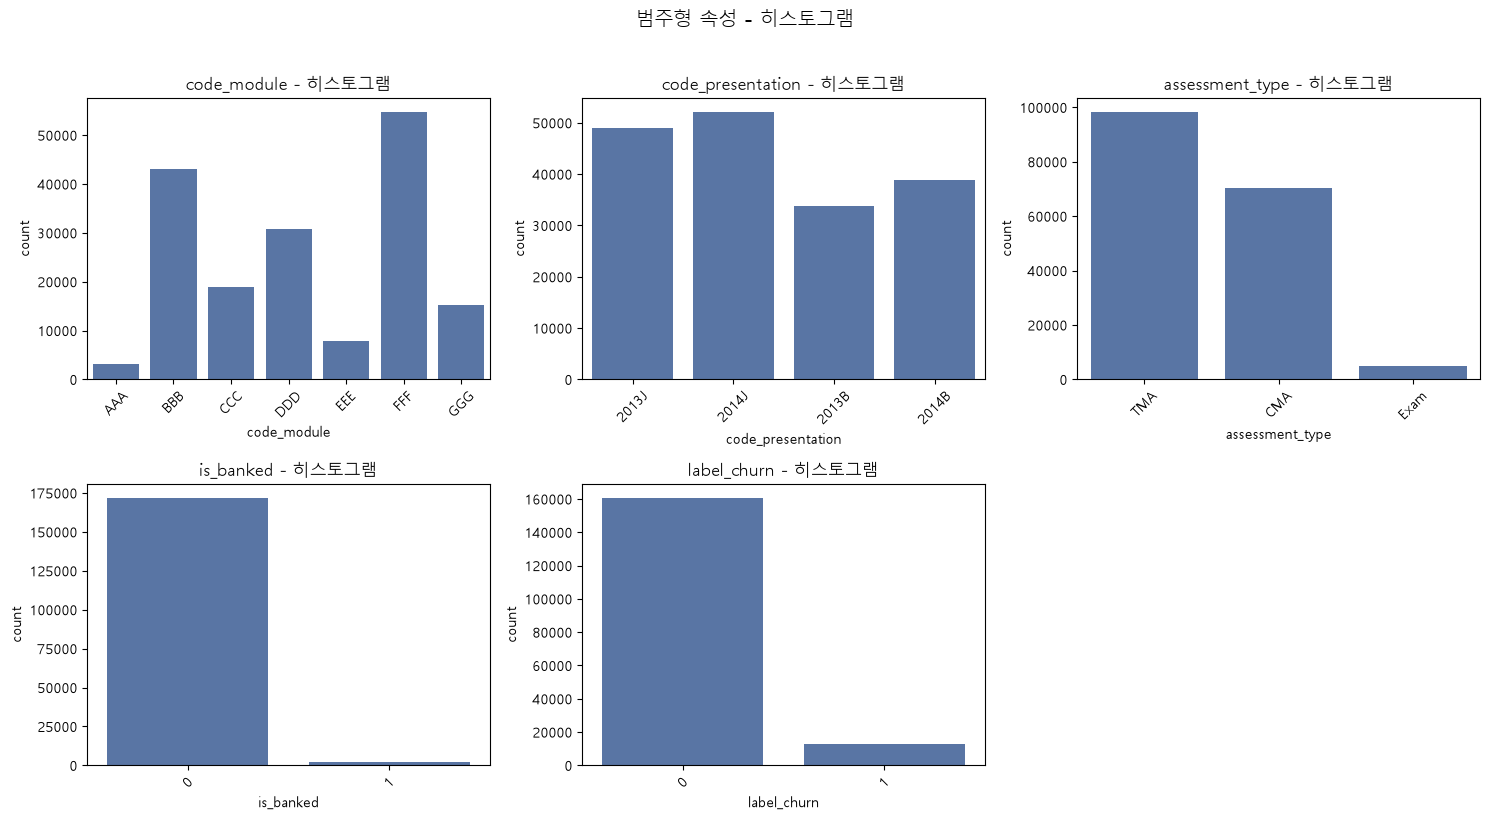

In [98]:
# 1-1 히스토그램(countplot)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 히스토그램')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

fig.suptitle('범주형 속성 - 히스토그램', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ! label_churn=1(이탈)이 전체 제출 건의 약 7.5%뿐 -> 제출 이력이 있는 학생 안에서는 이탈이 소수

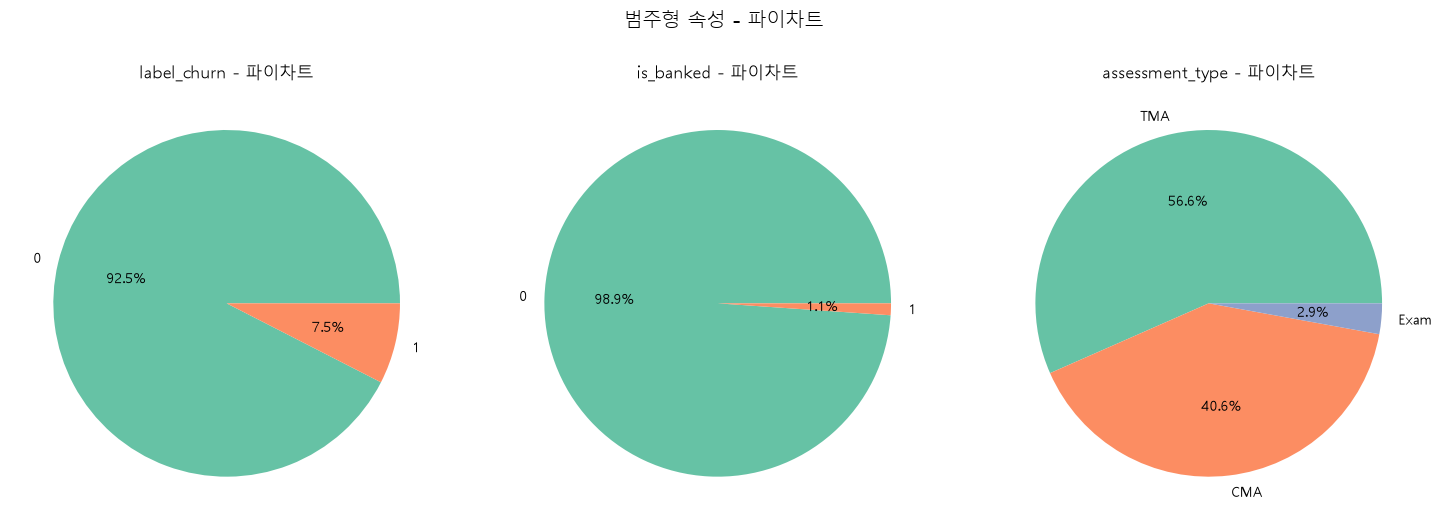

In [99]:
# 1-2 파이차트 (label_churn, is_banked, assessment_type만 - 범주 수가 적어 파이차트에 적합)

fig, axes = plt.subplots(1, len(pie_cols), figsize=(5 * len(pie_cols), 5))

for ax, col in zip(axes, pie_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index.astype(str), autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)))
    ax.set_title(f'{col} - 파이차트')

fig.suptitle('범주형 속성 - 파이차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

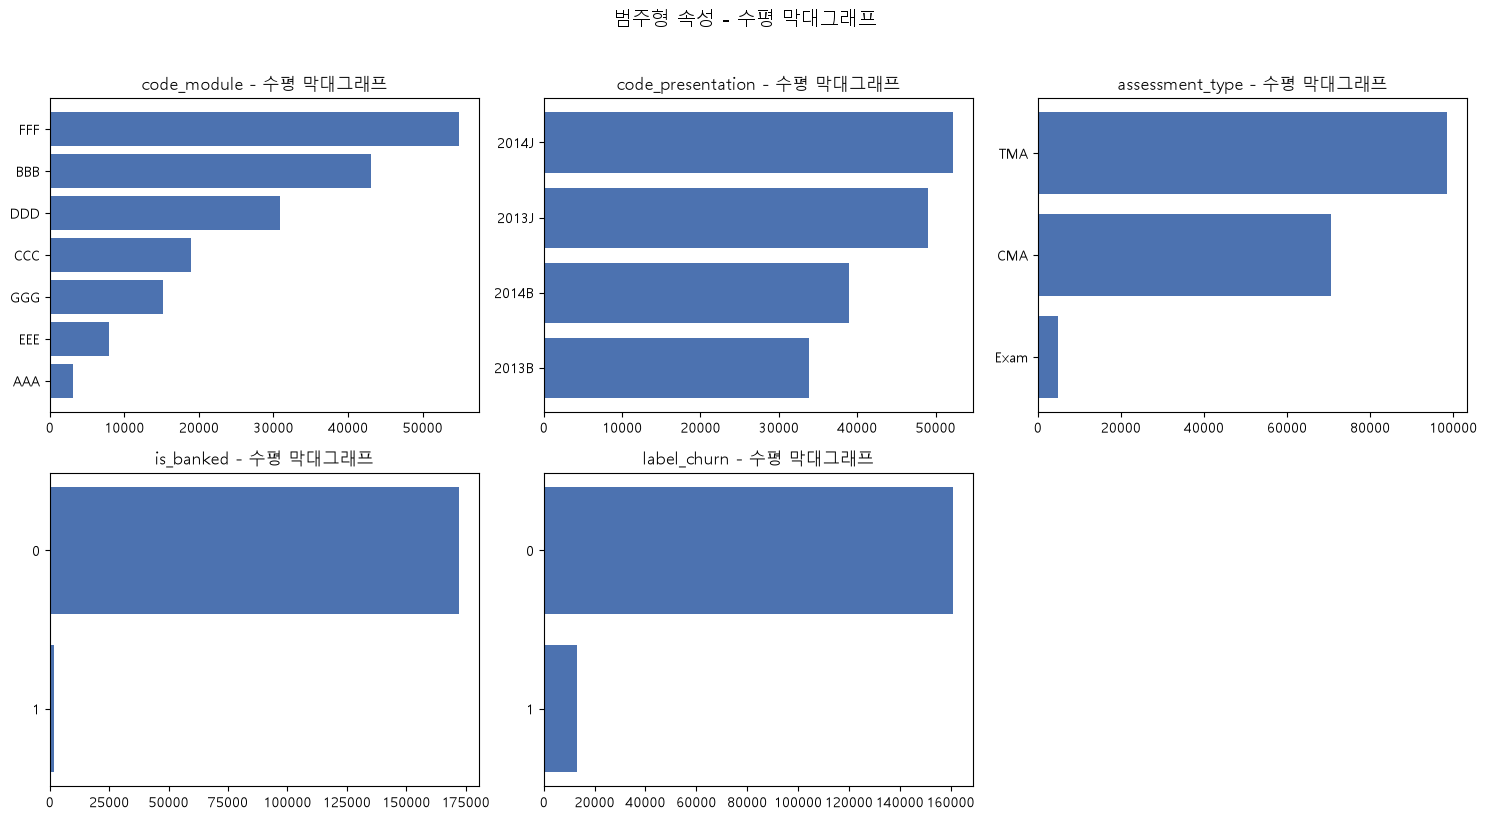

In [100]:
# 1-3 수평 막대그래프

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    ax.barh(counts.index.astype(str), counts.values, color='#4C72B0')
    ax.invert_yaxis()
    ax.set_title(f'{col} - 수평 막대그래프')

for ax in axes[len(cat_cols):]:
    fig.delaxes(ax)

fig.suptitle('범주형 속성 - 수평 막대그래프', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

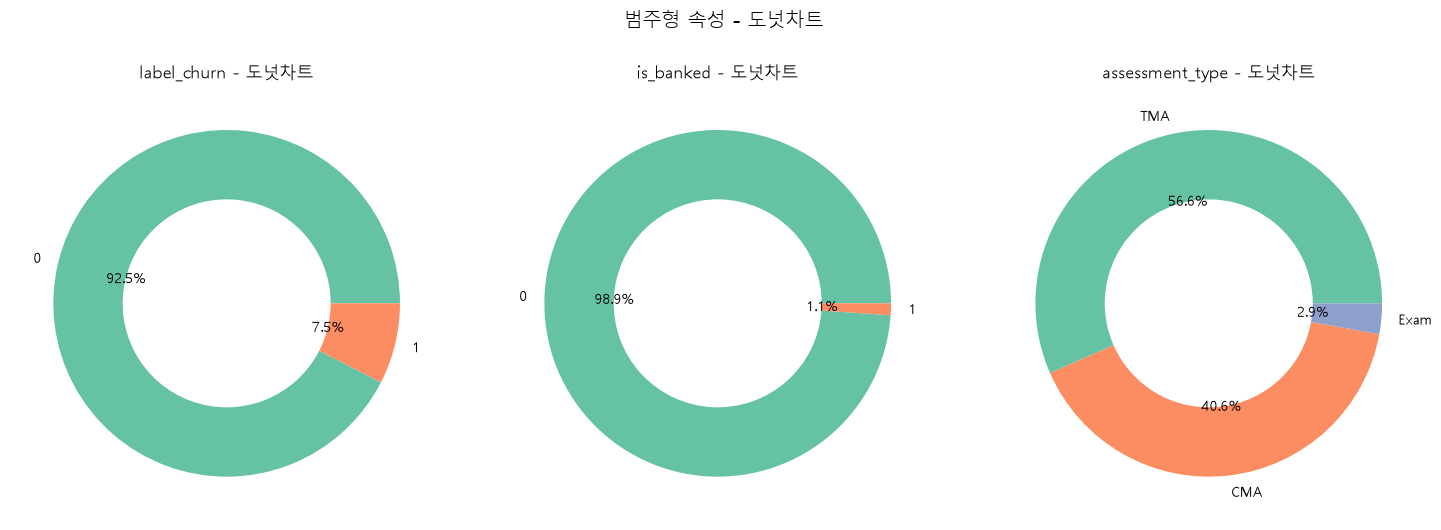

In [101]:
# 1-4 도넛차트 (label_churn, is_banked, assessment_type)

fig, axes = plt.subplots(1, len(pie_cols), figsize=(5 * len(pie_cols), 5))

for ax, col in zip(axes, pie_cols):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index.astype(str), autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(counts)), wedgeprops={'width': 0.4})
    ax.set_title(f'{col} - 도넛차트')

fig.suptitle('범주형 속성 - 도넛차트', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

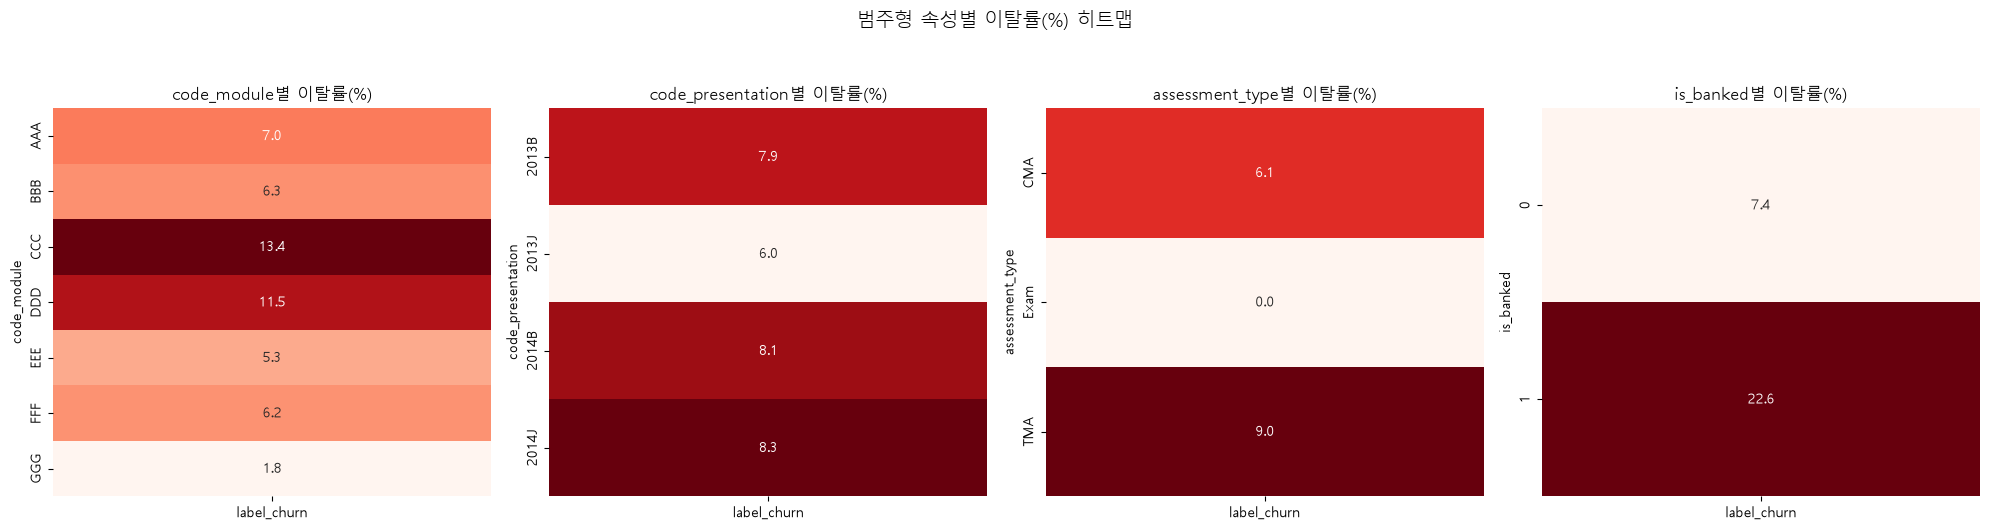

In [102]:
# 1-5 히트맵 - 범주형 속성별 '이탈률(%)' (단순 빈도가 아니라 label_churn 비율로 계산)
# Q 질문 도출 : 어떤 과목/평가유형/이월여부에서 이탈률이 특히 높은가?

other_cats = ['code_module', 'code_presentation', 'assessment_type', 'is_banked']
fig, axes = plt.subplots(1, len(other_cats), figsize=(5 * len(other_cats), 5))

for ax, col in zip(axes, other_cats):
    rate = df.groupby(col)['label_churn'].mean().to_frame() * 100
    sns.heatmap(rate, annot=True, fmt='.1f', cmap='Reds', cbar=False, ax=ax)
    ax.set_title(f'{col}별 이탈률(%)')

fig.suptitle('범주형 속성별 이탈률(%) 히트맵', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ! CCC 모듈, is_banked=1(이월결과), TMA/CMA 유형에서 이탈률이 상대적으로 높게 나타남

### 2. 수치형 그래프

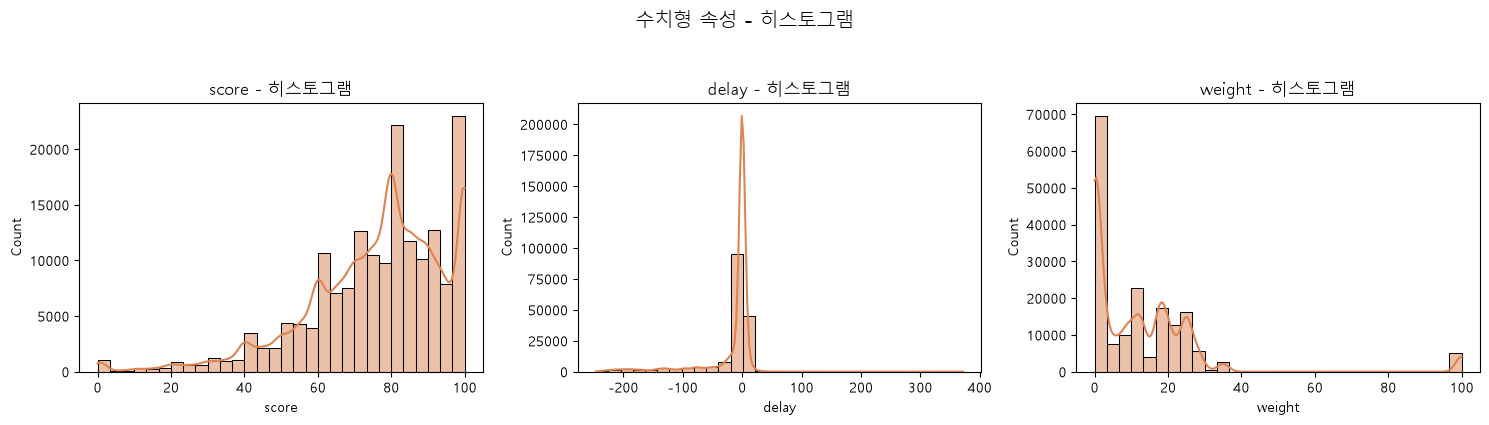

In [103]:
# 2-1 히스토그램(+KDE)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, color='#DD8452', ax=ax)
    ax.set_title(f'{col} - 히스토그램')
fig.suptitle('수치형 속성 - 히스토그램', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

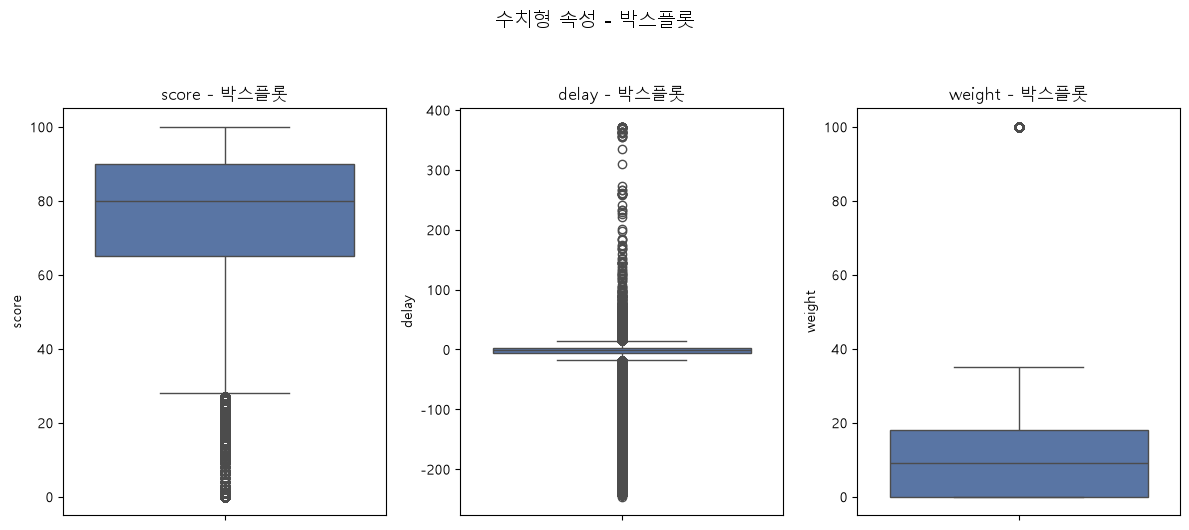

In [104]:
# 2-2 박스플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, color='#4C72B0', ax=ax)
    ax.set_title(f'{col} - 박스플롯')
fig.suptitle('수치형 속성 - 박스플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

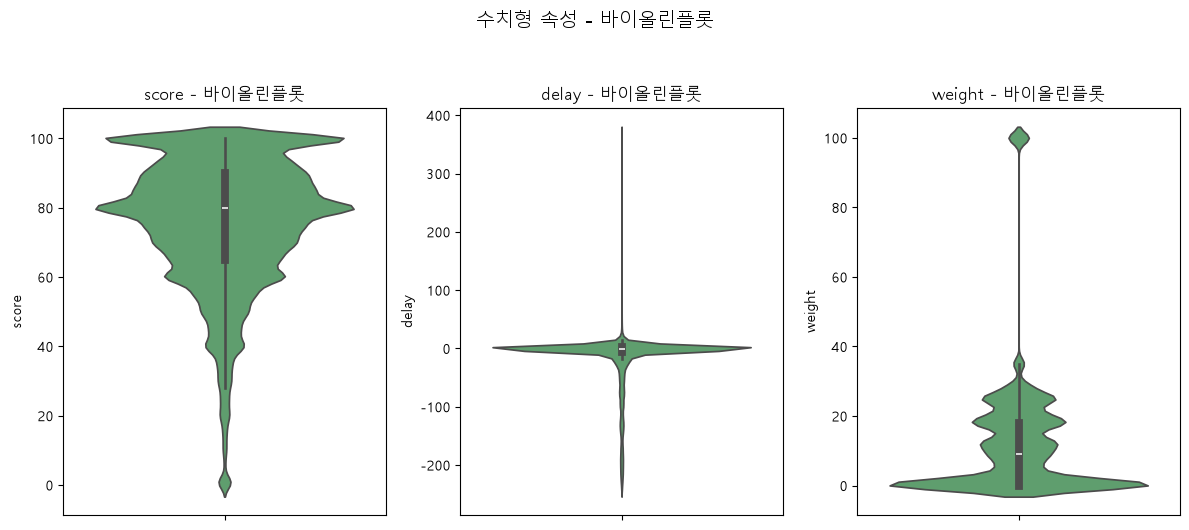

In [105]:
# 2-3 바이올린플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, y=col, color='#55A868', ax=ax)
    ax.set_title(f'{col} - 바이올린플롯')
fig.suptitle('수치형 속성 - 바이올린플롯', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [106]:
# 2-4 왜도/첨도 및 이상치(IQR)

for col in num_cols:
    s = df[col].dropna()
    print(f"[{col}] skew={s.skew():.3f}, kurt={s.kurt():.3f}")
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]
    print(f"  이상치 개수: {len(outliers)} (기준: {lower:.1f} ~ {upper:.1f})")

# delay는 왜도가 크게 음수 -> 대부분 마감 전후로 제출하지만 매우 이른 제출(음수 극단값)이 이상치로 많이 잡힘

[score] skew=-1.076, kurt=1.529
  이상치 개수: 3813 (기준: 27.5 ~ 127.5)
[delay] skew=-2.781, kurt=9.028
  이상치 개수: 32531 (기준: -18.0 ~ 14.0)
[weight] skew=3.270, kurt=13.356
  이상치 개수: 4959 (기준: -27.0 ~ 45.0)


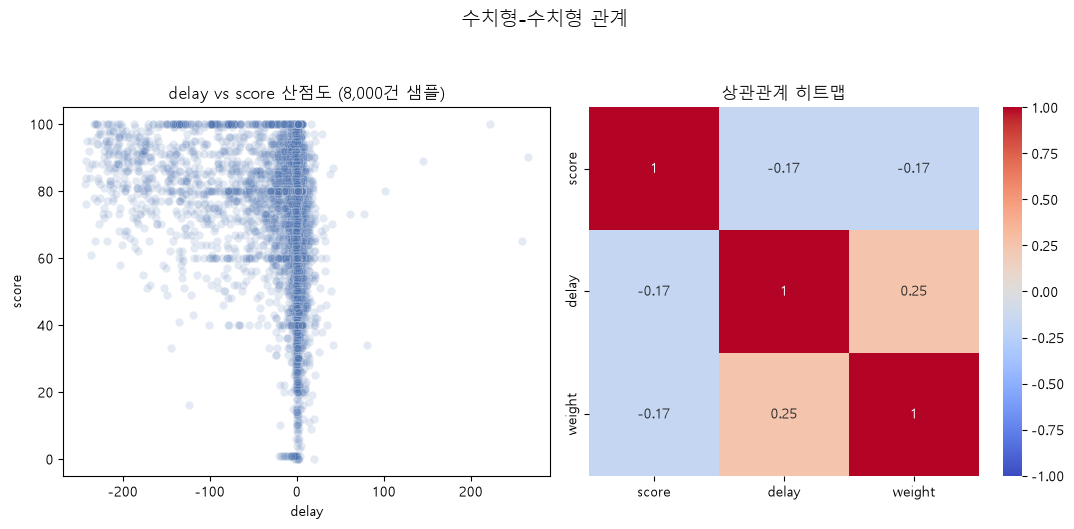

In [107]:
# 2-5 산점도, 상관관계 히트맵

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.scatterplot(data=df.sample(8000, random_state=42), x='delay', y='score', alpha=0.15, color='#4C72B0', ax=axes[0])
axes[0].set_title('delay vs score 산점도 (8,000건 샘플)')

corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('상관관계 히트맵')

fig.suptitle('수치형-수치형 관계', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# ? 지연 제출(delay 큼)일수록 점수가 낮아지는 경향이 있는가?

### 3. 범주형과 수치형 종합 그래프

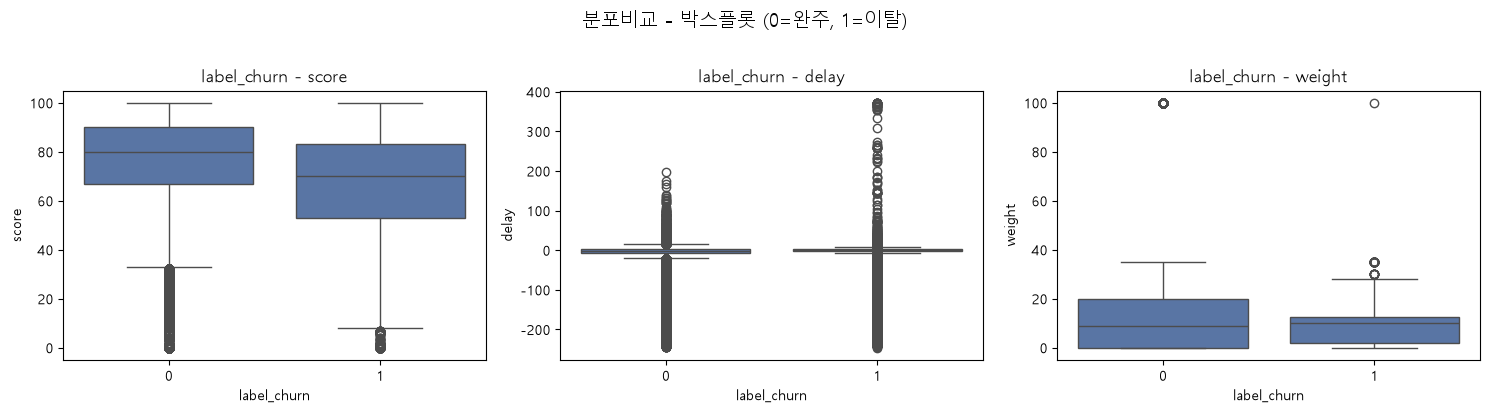

In [108]:
# 3-1 분포비교 - 박스플롯 (label_churn별)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, x='label_churn', y=col, color='#4C72B0', ax=ax)
    ax.set_title(f'label_churn - {col}')
fig.suptitle('분포비교 - 박스플롯 (0=완주, 1=이탈)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

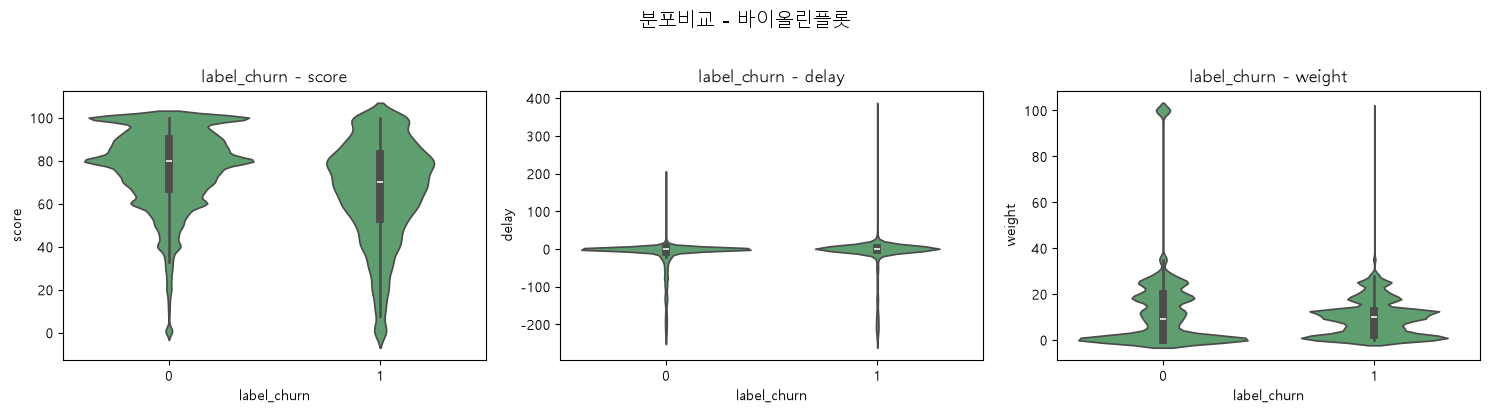

In [109]:
# 3-2 분포비교 - 바이올린플롯

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='label_churn', y=col, color='#55A868', ax=ax)
    ax.set_title(f'label_churn - {col}')
fig.suptitle('분포비교 - 바이올린플롯', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

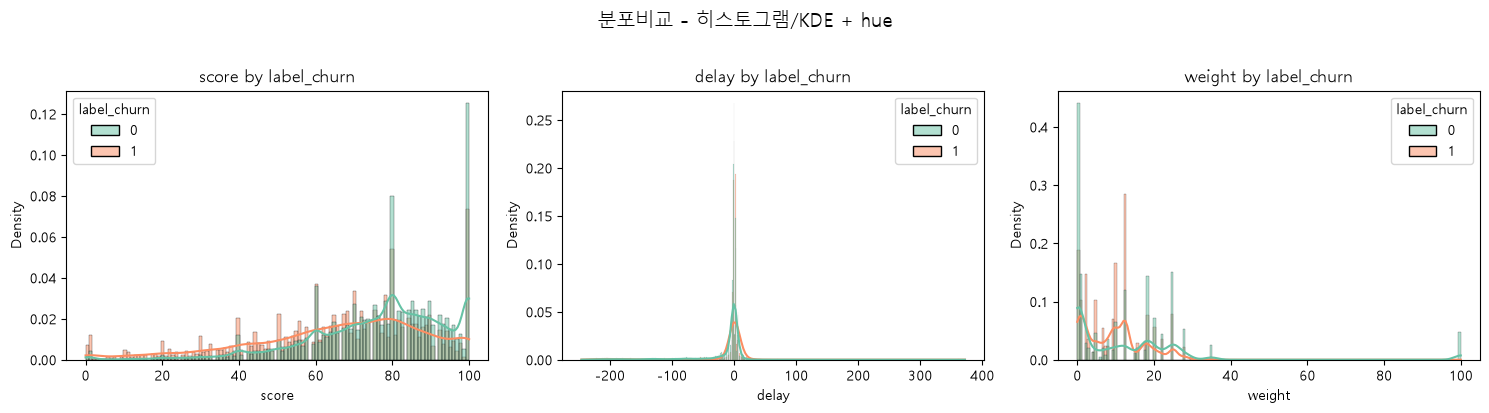

In [110]:
# 3-3 분포비교 - 히스토그램(+KDE) hue

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='label_churn', kde=True, palette='Set2', stat='density', common_norm=False, ax=ax)
    ax.set_title(f'{col} by label_churn')
fig.suptitle('분포비교 - 히스토그램/KDE + hue', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

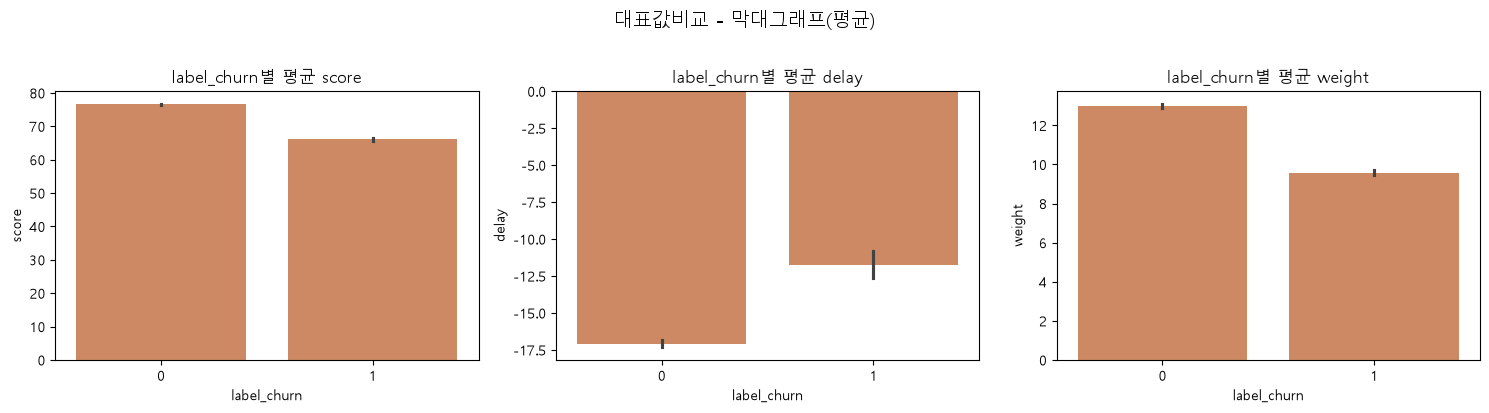

In [111]:
# 3-4 대표값 비교 - 막대그래프(평균)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.barplot(data=df, x='label_churn', y=col, color='#DD8452', ax=ax)
    ax.set_title(f'label_churn별 평균 {col}')
fig.suptitle('대표값비교 - 막대그래프(평균)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

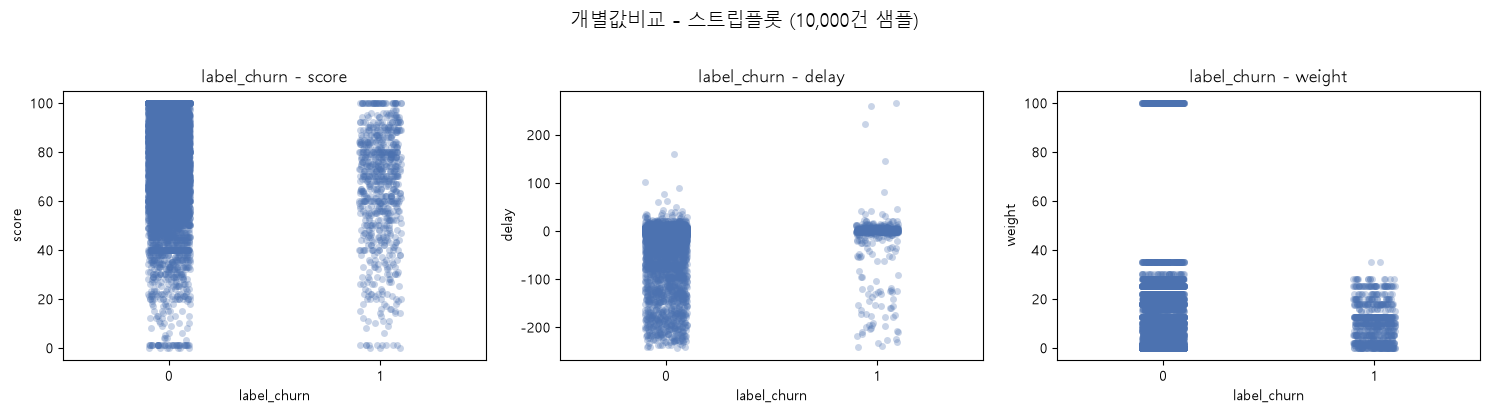

In [112]:
# 3-5 개별값 비교 - 스트립플롯 (10,000건 샘플링)

sample = df.sample(10000, random_state=42)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.stripplot(data=sample, x='label_churn', y=col, color='#4C72B0', alpha=0.3, ax=ax)
    ax.set_title(f'label_churn - {col}')
fig.suptitle('개별값비교 - 스트립플롯 (10,000건 샘플)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

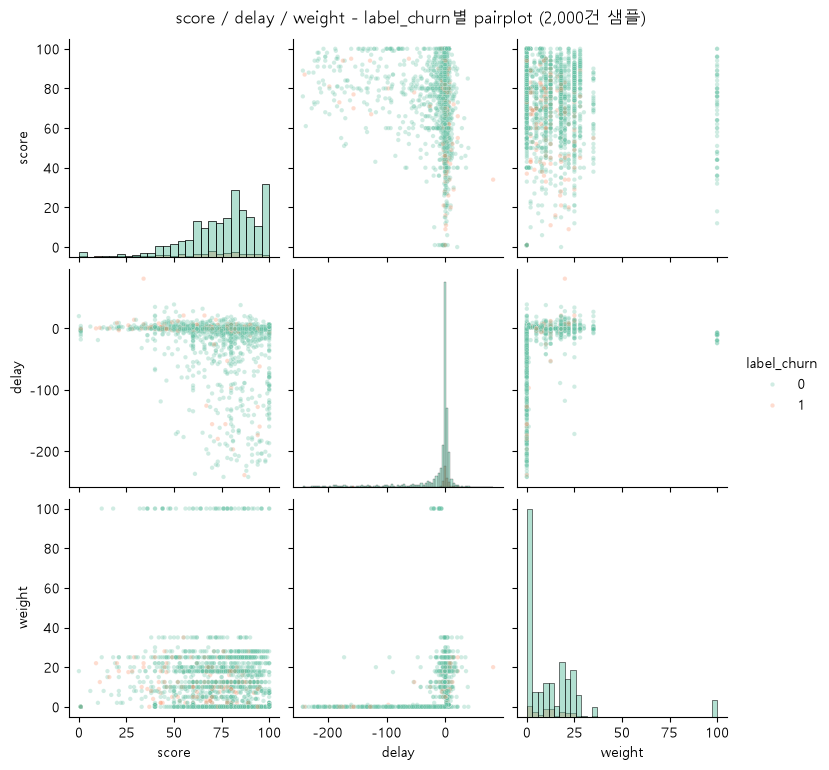

In [113]:
# 3-6 pairplot - 수치형 3개를 label_churn(이탈여부) 기준으로 한 번에 비교

pp = sns.pairplot(df.sample(2000, random_state=42), vars=num_cols, hue='label_churn',
                   palette='Set2', diag_kind='hist', plot_kws={'alpha': 0.3, 's': 10})
pp.fig.suptitle('score / delay / weight - label_churn별 pairplot (2,000건 샘플)', y=1.02)
plt.show()

## 5. 통계 검정이 필요한지

### 핵심 원칙
> **검정은 "질문"이 있을 때만 한다.**

이 노트북은 처음부터 `label_churn`(이탈 여부)이라는 명확한 두 집단을 갖고 시작한다. "이탈한
학생과 완주한 학생의 점수·제출 지연이 실제로 다른가?"라는 질문이 성립하므로 검정을 해볼 근거가
충분하다.

In [114]:
# score의 정규성 참고 확인 (5,000건 샘플)
sample_score = df['score'].dropna().sample(5000, random_state=42)
print('Shapiro(score):', stats.shapiro(sample_score))

g0_score = df[df['label_churn'] == 0]['score'].dropna()
g1_score = df[df['label_churn'] == 1]['score'].dropna()
u_stat, u_p = stats.mannwhitneyu(g0_score, g1_score, alternative='two-sided')
print(f'\n[score] Mann-Whitney U: stat={u_stat:.1f}, p={u_p:.4g}')
print('완주 평균/중앙값:', round(g0_score.mean(), 2), '/', g0_score.median(),
      ' 이탈 평균/중앙값:', round(g1_score.mean(), 2), '/', g1_score.median())

g0_delay = df[df['label_churn'] == 0]['delay'].dropna()
g1_delay = df[df['label_churn'] == 1]['delay'].dropna()
u_stat2, u_p2 = stats.mannwhitneyu(g0_delay, g1_delay, alternative='two-sided')
print(f'\n[delay] Mann-Whitney U: stat={u_stat2:.1f}, p={u_p2:.4g}')
print('완주 평균/중앙값:', round(g0_delay.mean(), 2), '/', g0_delay.median(),
      ' 이탈 평균/중앙값:', round(g1_delay.mean(), 2), '/', g1_delay.median())

Shapiro(score): ShapiroResult(statistic=np.float64(0.9245012764022004), pvalue=np.float64(1.342420208784443e-44))

[score] Mann-Whitney U: stat=1331213183.5, p=0
완주 평균/중앙값: 76.59 / 80.0  이탈 평균/중앙값: 66.08 / 70.0

[delay] Mann-Whitney U: stat=822029363.5, p=0
완주 평균/중앙값: -17.07 / -1.0  이탈 평균/중앙값: -11.74 / 0.0


### 결과 해석
- `score`는 정규분포가 아니고(Shapiro p<0.001), label_churn 두 그룹 사이에 Mann-Whitney U
  검정 결과 p<0.001로 유의한 차이가 있다 — 완주 그룹 평균 76.6점 vs 이탈 그룹 66.1점.
- `delay` 역시 p<0.001로 유의하지만, 평균 차이(-17.1일 vs -11.7일)는 방향이 직관과 다르다 —
  이탈 그룹이 오히려 완주 그룹보다 평균적으로 덜 이르게(마감에 더 가깝게) 제출한다는 뜻인데,
  두 그룹 모두 중앙값은 -1~0일로 큰 차이가 없어 평균은 소수의 극단적 조기 제출자에 의해 흔들린
  것일 수 있다. 중앙값·분포 모양을 함께 봐야 하는 사례다.
- 표본이 17만 건 이상으로 매우 크기 때문에, 작은 차이도 통계적으로는 쉽게 유의해진다는 점은
  이번에도 감안해야 한다. p-value보다 평균/중앙값 차이의 크기(effect size) 자체가 더 중요한
  정보다.

## 6. 조인된 데이터로 확인한 이탈률 관련 핵심 발견

### Q1. 제출 이력 유무 자체가 가장 강력한 이탈 신호다

#### 과정

In [115]:
# 근거 : 1-4 제출 이력 유무와 이탈률의 관계 (재인용)

roster.groupby('has_submission')['label_churn'].agg(['mean', 'count']).round(3)

,mean,count
has_submission,,
0.0,0.809,6750
1.0,0.182,25843


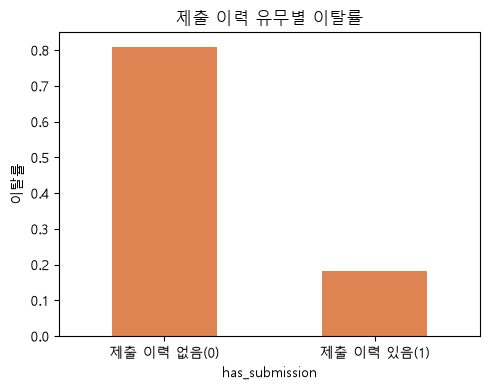

In [116]:
# Q1 보강: 제출 이력 유무별 이탈률 시각화

rate_q1 = roster.groupby('has_submission')['label_churn'].mean()

fig, ax = plt.subplots(figsize=(5, 4))
rate_q1.plot(kind='bar', color='#DD8452', ax=ax)
ax.set_title('제출 이력 유무별 이탈률')
ax.set_ylabel('이탈률')
ax.set_xticklabels(['제출 이력 없음(0)', '제출 이력 있음(1)'], rotation=0)
plt.tight_layout()
plt.show()

#### 설명

1장에서 이미 확인했지만 가장 중요한 결론이라 다시 강조한다. 평가를 한 번도 제출하지 않은
학생(6,750명, 20.7%)의 이탈률은 80.9%로, 제출 이력이 있는 학생(18.2%)의 4.4배다. 이 노트북의
조인 테이블(studentAssessment 기준)은 구조적으로 이 고위험군을 포함하지 못하므로, 뒤이은 모든
발견은 "이미 어느 정도 참여한 학생들 사이에서의 상대적 차이"로 해석해야 한다.

### Q2. 제출은 했지만 결국 이탈한 학생은 점수가 확연히 낮다

#### 과정

In [117]:
# 근거 : 5장 통계 검정

df.groupby('label_churn')['score'].agg(['mean', 'median', 'std', 'count']).round(2)

,mean,median,std,count
label_churn,,,,
0,76.59,80.0,18.17,160716
1,66.08,70.0,23.18,13023


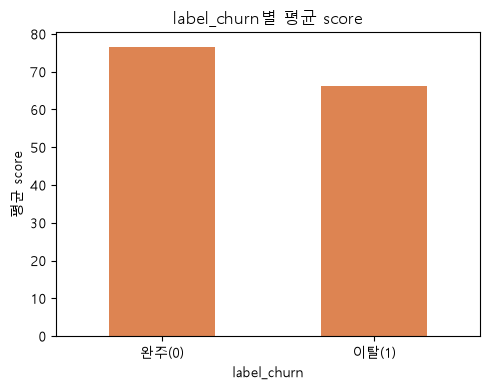

In [118]:
# Q2 보강: label_churn별 평균 score 시각화

fig, ax = plt.subplots(figsize=(5, 4))
df.groupby('label_churn')['score'].mean().plot(kind='bar', color='#DD8452', ax=ax)
ax.set_title('label_churn별 평균 score')
ax.set_ylabel('평균 score')
ax.set_xticklabels(['완주(0)', '이탈(1)'], rotation=0)
plt.tight_layout()
plt.show()

#### 설명

완주 그룹 평균 76.6점(중앙값 80) vs 이탈 그룹 평균 66.1점(중앙값 70)으로 10점 가까이 차이가
난다. 표준편차도 이탈 그룹이 더 커서(23.2 vs 18.2), 이탈 그룹 내에서 점수 편차 자체가 더
불안정하다. 다만 이 값은 "이탈하기 전까지 남긴 제출 기록의 점수"이므로, 점수가 낮아서
이탈했는지 이탈을 결심한 뒤 대충 제출했는지는 이 데이터만으로 인과를 가릴 수 없다.

### Q3. is_banked(이월 결과) 비율이 이탈 그룹에서 3배 이상 높다

#### 과정

In [119]:
# 근거 : 1-5 히트맵(이탈률)

pd.crosstab(df['label_churn'], df['is_banked'], normalize='index').round(4)

is_banked,0,1
label_churn,,
0,0.9908,0.0092
1,0.9671,0.0329


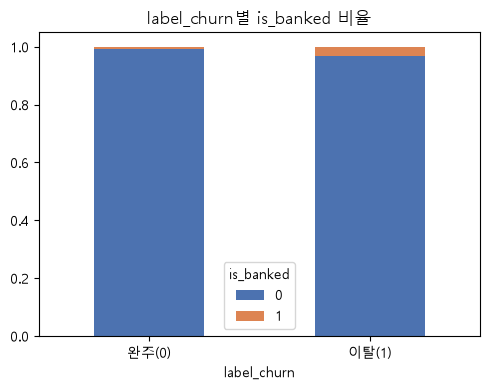

In [120]:
# Q3 보강: label_churn별 is_banked 비율 시각화

fig, ax = plt.subplots(figsize=(5, 4))
pd.crosstab(df['label_churn'], df['is_banked'], normalize='index').plot(
    kind='bar', stacked=True, ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('label_churn별 is_banked 비율')
ax.set_xticklabels(['완주(0)', '이탈(1)'], rotation=0)
plt.tight_layout()
plt.show()

#### 설명

완주 그룹은 is_banked=1 비율이 0.9%인데 이탈 그룹은 3.3%로 3배 이상 높다. is_banked=1은
이전 학기 결과가 그대로 이월된 경우라, 이번 학기에 실제로 참여하지 않았을 가능성이 큰
케이스였다(02번 노트북 Q4 참고). 이 비율이 이탈 그룹에서 더 높다는 것은 "이번 학기 재도전을
하다가 실제로는 이전 결과에 의존하고 이탈한" 학생이 상대적으로 더 많을 수 있다는 정황이다.

### Q4. 평가 유형(assessment_type)별로 이탈률이 크게 다르다

#### 과정

In [121]:
# 근거 : 1-5 히트맵(이탈률)

df.groupby('assessment_type')['label_churn'].agg(['mean', 'count']).round(4)

,mean,count
assessment_type,,
CMA,0.0606,70527
Exam,0.0002,4959
TMA,0.0896,98426


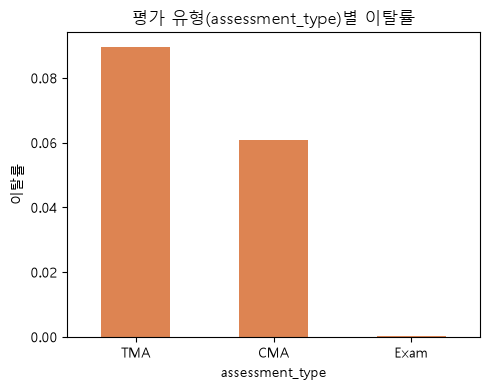

In [122]:
# Q4 보강: 평가 유형별 이탈률 시각화

fig, ax = plt.subplots(figsize=(5, 4))
df.groupby('assessment_type')['label_churn'].mean().sort_values(ascending=False).plot(
    kind='bar', color='#DD8452', ax=ax)
ax.set_title('평가 유형(assessment_type)별 이탈률')
ax.set_ylabel('이탈률')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 설명

Exam 제출 건 중 이탈 그룹 비율은 0.02%(4,959건 중 1건)로 사실상 0에 가깝다. 이는 당연한
결과에 가깝다 — 이미 이탈한 학생은 학기 말 시험(Exam) 자체를 치를 일이 거의 없기 때문이다.
반면 TMA는 9.0%, CMA는 6.1%로 상대적으로 이탈 비율이 있다. 즉 "이탈 학생이 남긴 마지막
제출"은 대부분 학기 초중반의 TMA/CMA이지 Exam이 아니다.

### Q5. 과목(code_module)별 이탈률 차이가 여전히 크다

#### 과정

In [123]:
# 근거 : 1-5 히트맵(이탈률)

df.groupby('code_module')['label_churn'].mean().sort_values(ascending=False).round(4)

code_module
CCC    0.1341
DDD    0.1147
AAA    0.0699
BBB    0.0625
FFF    0.0621
EEE    0.0533
GGG    0.0183
Name: label_churn, dtype: float64

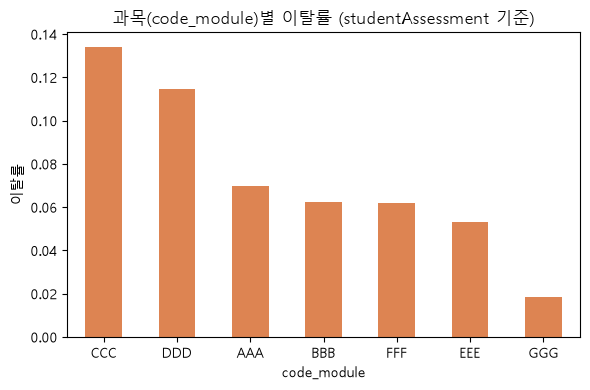

In [124]:
# Q5 보강: 과목별 이탈률 시각화 (studentAssessment 기준)

fig, ax = plt.subplots(figsize=(6, 4))
df.groupby('code_module')['label_churn'].mean().sort_values(ascending=False).plot(
    kind='bar', color='#DD8452', ax=ax)
ax.set_title('과목(code_module)별 이탈률 (studentAssessment 기준)')
ax.set_ylabel('이탈률')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### 설명

CCC(약 11~12%)가 가장 높고 다른 과목은 그보다 낮은 편으로, 03번(courses.csv) 노트북에서
확인했던 "CCC는 2013년도에 개설되지 않았다"는 구조와 무관하지 않을 수 있다. 다만 이 수치는
studentAssessment 기준(제출 이력이 있는 건)의 이탈률이라 studentInfo 전체 기준 이탈률(1장,
CCC 44.5%)보다 훨씬 낮게 보인다 — Q1에서 짚은 대로 이 표에 없는 '제출 이력 자체가 없는'
고위험군이 과목마다 다른 비율로 빠져 있기 때문일 수 있어, 과목별 비교는 studentInfo 기준
수치(1장)를 기준으로 삼는 것이 더 정확하다.

### Q6. weight(평가 비중)가 낮은 제출일수록 이탈 그룹에 더 많이 몰려 있다

#### 과정

In [125]:
# 근거 : 3-1 분포비교 박스플롯

df.groupby('label_churn')['weight'].agg(['mean', 'median', 'std']).round(2)

,mean,median,std
label_churn,,,
0,13.00,9.0,18.44
1,9.57,10.0,7.66


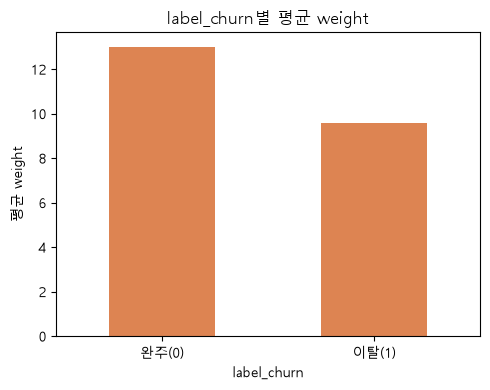

In [126]:
# Q6 보강: label_churn별 평균 weight 시각화

fig, ax = plt.subplots(figsize=(5, 4))
df.groupby('label_churn')['weight'].mean().plot(kind='bar', color='#DD8452', ax=ax)
ax.set_title('label_churn별 평균 weight')
ax.set_ylabel('평균 weight')
ax.set_xticklabels(['완주(0)', '이탈(1)'], rotation=0)
plt.tight_layout()
plt.show()

#### 설명

완주 그룹은 weight 평균 13.0(표준편차 18.4)인데 이탈 그룹은 평균 9.6(표준편차 7.7)으로 더
작고 더 고르다. 이는 이탈 그룹의 제출 기록이 주로 비중이 작은 초반 과제(TMA/CMA)에 몰려
있고, 비중이 큰 후반 과제나 Exam(보통 weight=100)까지는 도달하지 못했다는 Q4의 결과와 같은
방향이다.

## 7. 다른 CSV 파일과 더 연관지어야 확인할 수 있는 것들

### 질문

- **courses.csv를 추가로 조인**해 `module_presentation_length`, 개강 시즌(B/J)을 통제하면,
  Q5(과목별 이탈률 차이)가 실제로 과목 자체의 문제인지 학기 구조(길이·시즌)의 문제인지 분리할
  수 있다.
- **studentRegistration.csv의 `date_unregistration`을 추가로 조인**하면 "언제 이탈했는지"를
  알 수 있어, 학생별 마지막 제출일(`date_submitted`의 최댓값)과 실제 등록취소일 사이의 간격을
  계산할 수 있다. 이건 애초에 이 3단계 조인 계획을 시작한 핵심 목적이기도 하다 — 제출을 멈춘
  시점과 공식적으로 이탈한 시점이 얼마나 떨어져 있는지 확인하는 것.
- **studentVle.csv를 추가로 조인**하면 이탈 그룹이 마지막 제출 전후로 온라인 학습활동(클릭
  수)이 실제로 줄어들었는지, Q1에서 확인한 '제출 이력 자체가 없는' 고위험군이 그래도
  로그인/클릭 기록은 남겼는지(즉 완전히 발길을 끊은 건 아닌지) 확인할 수 있다.
- Q1에서 짚은 대표성 문제를 보완하려면, 이 노트북의 조인 테이블과는 별도로 **studentInfo.csv
  전체(32,593건) 기준의 이탈률**을 항상 함께 병기해서, "제출 이력이 있는 학생 안에서의 패턴"과
  "전체 학생 기준 이탈률"을 혼동하지 않도록 해야 한다.
- Q3(is_banked)의 해석을 확정하려면 studentRegistration.csv의 `date_registration`(등록 시점)과
  비교해, 이월 결과를 받은 학생이 이번 학기에 아예 등록조차 늦었는지 등을 함께 봐야 한다.